In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../data/default of credit card clients.xls', header=1, engine='xlrd')

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.shape

(30000, 25)

In [5]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [6]:
df['default payment next month'].value_counts(normalize=True) * 100

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64

In [7]:
df = df.rename(columns={'default payment next month': 'default'})
df.drop('ID', axis=1, inplace=True)

In [8]:
df.dtypes

LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
default      int64
dtype: object

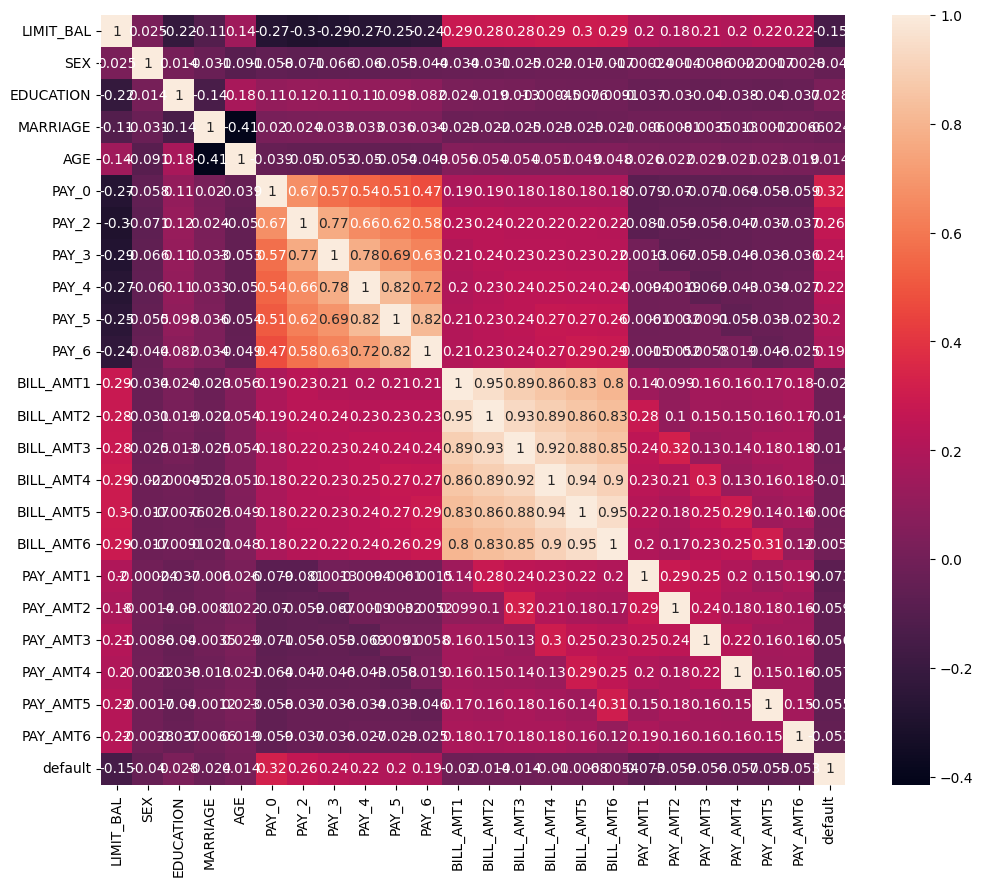

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True)
plt.show()

# Train / Test Split

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop("default", axis=1)
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model with MLflow Tracking

In [14]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

mlflow.set_tracking_uri("file:///E:/credit_default_ml/notebooks/mlruns")
mlflow.set_experiment("credit_default")


with mlflow.start_run():

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:,1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    f1 = f1_score(y_test, preds)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", auc)
    mlflow.log_metric("f1_score", f1)

    mlflow.sklearn.log_model(model, "model2")

print(acc, auc, f1)

2026/03/05 13:58:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 13:58:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


0.8076666666666666 0.7076355036089734 0.3553072625698324


In [15]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("credit_default")

with mlflow.start_run(run_name="baseline_logistic_regression"):

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:,1]

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    f1 = f1_score(y_test, preds)

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("roc_auc", auc)
    mlflow.log_metric("f1_score", f1)

    mlflow.sklearn.log_model(model, "model")

print(acc, auc, f1)

e:\credit_default_ml\ucivenv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/05 14:10:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 14:10:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


0.8076666666666666 0.7076355036089734 0.3553072625698324


In [16]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("credit_default")

C_values = [0.001, 0.01, 0.1, 1, 10]

for C in C_values:

    with mlflow.start_run(run_name=f"logreg_C_{C}"):

        model = LogisticRegression(C=C, max_iter=1000)

        model.fit(X_train_scaled, y_train)

        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]

        acc = accuracy_score(y_test, preds)
        auc = roc_auc_score(y_test, probs)
        f1 = f1_score(y_test, preds)

        mlflow.log_param("C", C)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("roc_auc", auc)
        mlflow.log_metric("f1_score", f1)

        mlflow.sklearn.log_model(model, "model")

        print(f"C={C} | Accuracy={acc:.4f} | ROC_AUC={auc:.4f}")

2026/03/05 14:11:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 14:11:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/05 14:11:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 14:11:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

C=0.001 | Accuracy=0.8023 | ROC_AUC=0.7033


2026/03/05 14:11:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 14:11:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


C=0.01 | Accuracy=0.8070 | ROC_AUC=0.7067


2026/03/05 14:11:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 14:11:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


C=0.1 | Accuracy=0.8077 | ROC_AUC=0.7075


2026/03/05 14:11:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/05 14:11:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


C=1 | Accuracy=0.8077 | ROC_AUC=0.7076
C=10 | Accuracy=0.8075 | ROC_AUC=0.7077
